# Support Vector Machine Classifer

This notebook will explore the use of SVM to predict hyper- and hypothyroid conditions.

## Import Packages

In [22]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, fbeta_score, make_scorer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.svm import SVC
from imblearn.pipeline import Pipeline
from imblearn.combine import SMOTEENN
from imblearn.over_sampling import SMOTE


## Read-In Data

In [23]:
X_train = pd.read_csv('train.csv')
X_test = pd.read_csv('test.csv')
y_train = np.array(pd.read_csv('train_labels.csv')).reshape(-1,)
y_test = np.array(pd.read_csv('test_labels.csv')).reshape(-1,)

## Run SVM

Hyperparameters:

C: Larger C means prioritizing correct classification over margin

Gamma (Only for Kernelized): inverse of the scale of the gaussian kernel function, larger means smaller more constrained kernels.

### Create Score Function

Since our priority in the medical field on low cost front line diagnostic tests is to detect disorders, our training priority should focus on recall. The blood tests in the data and the medical history and demographic information are cheap in both time and money. The consequences of missing a diagnosis therefore greatly outweigh flagging patients for futher follow-up incorrectly. Thus, we should prioritize on recall as our tuning metric. This function calculates the f_2 score across all three classes and reports the lowest.

In [24]:
def score(y_true, y_pred):
    return np.array(fbeta_score(y_true, y_pred, average=None, beta=2)).min()

scorer = make_scorer(score)

### No Class Imblance Fix

The classes are very imbalanced in the data, but we shall see how correcting for that with SMOTE and SMOTEENN algorithms changes the recall rate.

#### Linear

##### Find Optimal C

In [25]:
c_vals = np.logspace(-1, 1, 25)
param_grid = {'svc__C': c_vals}
pipe = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=2)),
    ('ss', StandardScaler()),
    ('svc', SVC(random_state=6740, kernel='linear')),
    ])
svc_linear = GridSearchCV(pipe, param_grid, cv=5, scoring=scorer)
svc_linear = svc_linear.fit(X_train, y_train)

The best C value is 1.21 with a f_2 score of 0.4888


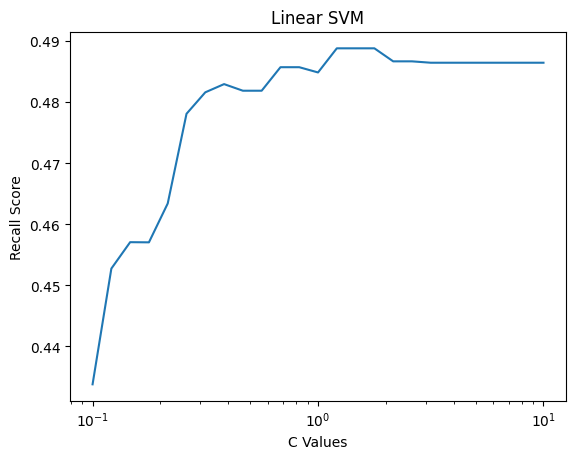

In [26]:
print(f'The best C value is {svc_linear.best_params_["svc__C"]:.2f} with a f_2 score of {svc_linear.best_score_:.4f}')
plt.plot(c_vals, svc_linear.cv_results_['mean_test_score'])
plt.xscale('log')
plt.xlabel('C Values')
plt.ylabel('Recall Score')
plt.title('Linear SVM')
plt.show()

##### Use Optimal C

In [35]:
print(classification_report(y_test, svc_linear.best_estimator_.predict(X_test)))

              precision    recall  f1-score   support

           0       0.96      0.99      0.97      1679
           1       0.87      0.51      0.65       119
           2       0.75      0.58      0.66        36

    accuracy                           0.95      1834
   macro avg       0.86      0.70      0.76      1834
weighted avg       0.95      0.95      0.95      1834



#### Kernelized (RBF)

##### Find Optimal C and Gamma

In [39]:
c_vals = np.logspace(0, 2, 10)
gamma_vals = np.logspace(-2, 0, 10)
param_grid = {'svc__C': c_vals, 'svc__gamma': gamma_vals}
pipe = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=2)),
    ('ss', StandardScaler()),
    ('svc', SVC(random_state=6740, kernel='rbf')),
    ])
svc_rbf = GridSearchCV(pipe, param_grid, cv=5, scoring=scorer)
svc_rbf = svc_rbf.fit(X_train, y_train)

The best C value is 13 and the best gamma value is 0.0278 with a f_2 score of 0.6200


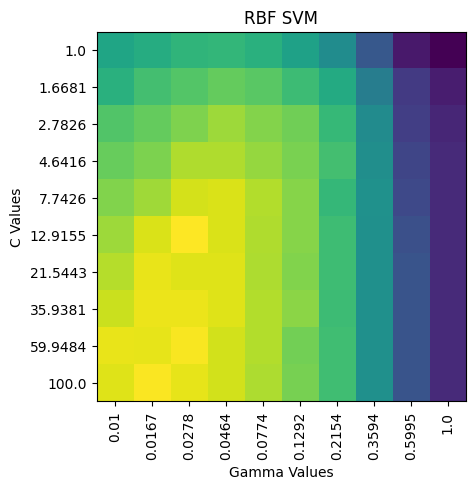

In [40]:
print(f'The best C value is {svc_rbf.best_params_["svc__C"]:.0f} and the best gamma value is {svc_rbf.best_params_["svc__gamma"]:.4f} with a f_2 score of {svc_rbf.best_score_:.4f}')

plt.imshow(svc_rbf.cv_results_['mean_test_score'].reshape(len(gamma_vals), len(c_vals)))
plt.xticks(np.arange(len(gamma_vals)), gamma_vals.round(4), rotation=90)
plt.xlabel('Gamma Values')
plt.yticks(np.arange(len(c_vals)), c_vals.round(4))
plt.title('RBF SVM')
plt.ylabel('C Values')
plt.show()

##### Use Optimal C and Gamma

In [41]:
print(classification_report(y_test, svc_rbf.best_estimator_.predict(X_test)))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1679
           1       0.87      0.67      0.76       119
           2       0.66      0.53      0.58        36

    accuracy                           0.96      1834
   macro avg       0.83      0.73      0.77      1834
weighted avg       0.95      0.96      0.96      1834



### With SMOTE

#### Linear

##### Find Optimal C

In [31]:
c_vals = np.logspace(-1, 1, 25)
param_grid = {'svc__C': c_vals}
pipe = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=2)),
    ('ss', StandardScaler()),
    ('smote', SMOTE(random_state=6740)),
    ('svc', SVC(random_state=6740, kernel='linear')),
    ])
svc_linear_smote = GridSearchCV(pipe, param_grid, cv=5, scoring=scorer)
svc_linear_smote = svc_linear_smote.fit(X_train, y_train)

The best C value is 0.46 with a f_2 score of 0.6376


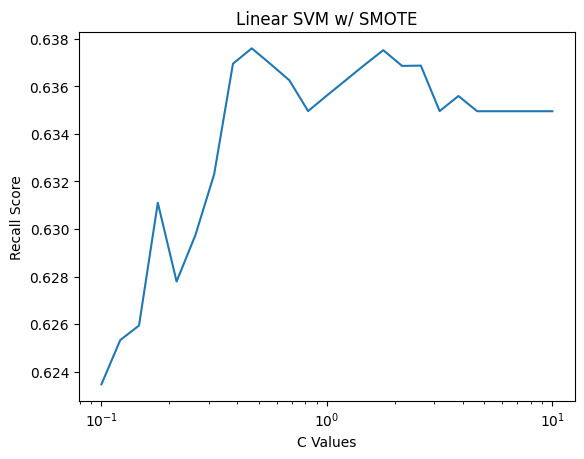

In [32]:
print(f'The best C value is {svc_linear_smote.best_params_["svc__C"]:.2f} with a f_2 score of {svc_linear_smote.best_score_:.4f}')
plt.plot(c_vals, svc_linear_smote.cv_results_['mean_test_score'])
plt.xscale('log')
plt.title('Linear SVM w/ SMOTE')
plt.xlabel('C Values')
plt.ylabel('Recall Score')
plt.show()

##### Use Optimal C

In [37]:
print(classification_report(y_test, svc_linear_smote.best_estimator_.predict(X_test)))

              precision    recall  f1-score   support

           0       1.00      0.91      0.95      1679
           1       0.63      1.00      0.78       119
           2       0.28      0.94      0.43        36

    accuracy                           0.91      1834
   macro avg       0.64      0.95      0.72      1834
weighted avg       0.96      0.91      0.93      1834



#### Kernalized (RBF)

##### Find Optimal C and Gamma

In [54]:
c_vals = np.logspace(-1, 3, 10)
gamma_vals = np.logspace(-3, 0, 10)
param_grid = {'svc__C': c_vals, 'svc__gamma': gamma_vals}
pipe = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=2)),
    ('ss', StandardScaler()),
    ('smote', SMOTE(random_state=6740)),
    ('svc', SVC(random_state=6740, kernel='rbf')),
    ])
svc_rbf_smote = GridSearchCV(pipe, param_grid, cv=5, scoring=scorer)
svc_rbf_smote = svc_rbf_smote.fit(X_train, y_train)

The best C value is 129 and the best gamma value is 0.0022 with a f_2 score of 0.7184


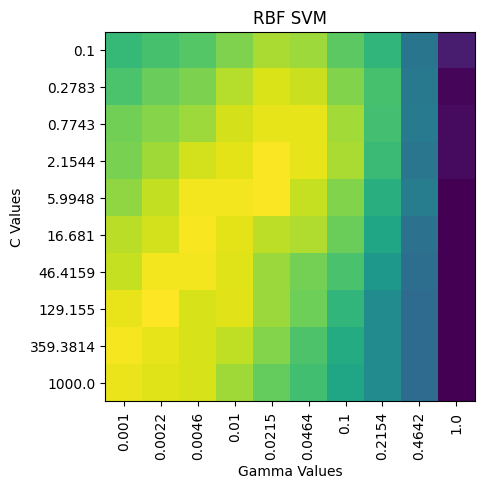

In [55]:
print(f'The best C value is {svc_rbf_smote.best_params_["svc__C"]:.0f} and the best gamma value is {svc_rbf_smote.best_params_["svc__gamma"]:.4f} with a f_2 score of {svc_rbf_smote.best_score_:.4f}')

plt.imshow(svc_rbf_smote.cv_results_['mean_test_score'].reshape(len(gamma_vals), len(c_vals)))
plt.xticks(np.arange(len(gamma_vals)), gamma_vals.round(4), rotation=90)
plt.xlabel('Gamma Values')
plt.yticks(np.arange(len(c_vals)), c_vals.round(4))
plt.title('RBF SVM')
plt.ylabel('C Values')
plt.show()

##### Use Optimal C and Gamma

In [56]:
print(classification_report(y_test, svc_rbf_smote.best_estimator_.predict(X_test)))

              precision    recall  f1-score   support

           0       0.99      0.95      0.97      1679
           1       0.74      0.95      0.83       119
           2       0.40      0.78      0.53        36

    accuracy                           0.95      1834
   macro avg       0.71      0.89      0.78      1834
weighted avg       0.96      0.95      0.95      1834



### With SMOTEENN

#### Linear

##### Find Optimal C

In [33]:
c_vals = np.logspace(-2, 1, 25)
param_grid = {'svc__C': c_vals}
pipe = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=2)),
    ('ss', StandardScaler()),
    ('smoteenn', SMOTEENN(random_state=6740)),
    ('svc', SVC(random_state=6740, kernel='linear')),
    ])
svc_linear_smoteenn = GridSearchCV(pipe, param_grid, cv=5, scoring=scorer)
svc_linear_smoteenn = svc_linear_smoteenn.fit(X_train, y_train)

The best C value is 1.78 with a f_2 score of 0.6302


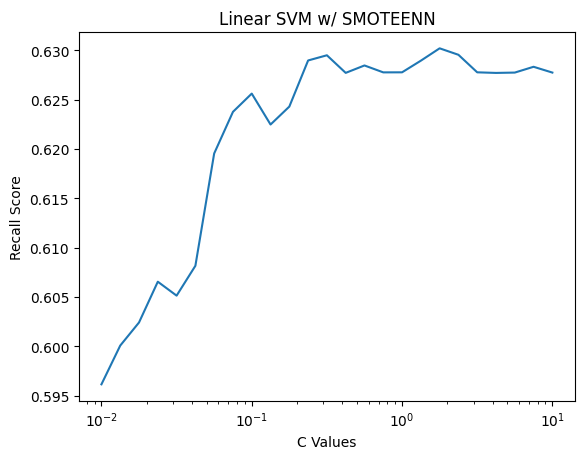

In [34]:
print(f'The best C value is {svc_linear_smoteenn.best_params_["svc__C"]:.2f} with a f_2 score of {svc_linear_smoteenn.best_score_:.4f}')
plt.plot(c_vals, svc_linear_smoteenn.cv_results_['mean_test_score'])
plt.xscale('log')
plt.xlabel('C Values')
plt.title('Linear SVM w/ SMOTEENN')
plt.ylabel('Recall Score')
plt.show()

##### Use Optimal C

In [38]:
print(classification_report(y_test, svc_linear_smoteenn.best_estimator_.predict(X_test)))

              precision    recall  f1-score   support

           0       1.00      0.90      0.95      1679
           1       0.64      1.00      0.78       119
           2       0.26      0.94      0.40        36

    accuracy                           0.91      1834
   macro avg       0.63      0.95      0.71      1834
weighted avg       0.96      0.91      0.93      1834



#### Kernalized (RBF)

##### Find Optimal C and Gamma

In [57]:
c_vals = np.logspace(-1, 3, 10)
gamma_vals = np.logspace(-3, 0, 10)
param_grid = {'svc__C': c_vals, 'svc__gamma': gamma_vals}
pipe = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=2)),
    ('ss', StandardScaler()),
    ('smoteenn', SMOTEENN(random_state=6740)),
    ('svc', SVC(random_state=6740, kernel='rbf')),
    ])
svc_rbf_smoteenn = GridSearchCV(pipe, param_grid, cv=5, scoring=scorer)
svc_rbf_smoteenn = svc_rbf_smoteenn.fit(X_train, y_train)

The best C value is 17 and the best gamma value is 0.0046 with a f_2 score of 0.7212


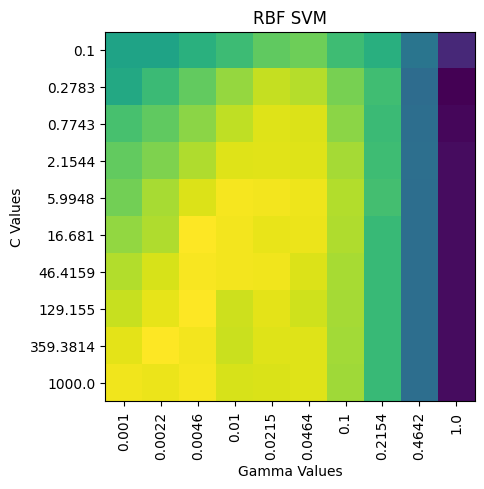

In [58]:
print(f'The best C value is {svc_rbf_smoteenn.best_params_["svc__C"]:.0f} and the best gamma value is {svc_rbf_smoteenn.best_params_["svc__gamma"]:.4f} with a f_2 score of {svc_rbf_smoteenn.best_score_:.4f}')

plt.imshow(svc_rbf_smoteenn.cv_results_['mean_test_score'].reshape(len(gamma_vals), len(c_vals)))
plt.xticks(np.arange(len(gamma_vals)), gamma_vals.round(4), rotation=90)
plt.xlabel('Gamma Values')
plt.yticks(np.arange(len(c_vals)), c_vals.round(4))
plt.title('RBF SVM')
plt.ylabel('C Values')
plt.show()

##### Use Optimal C and Gamma

In [59]:
print(classification_report(y_test, svc_rbf_smoteenn.best_estimator_.predict(X_test)))

              precision    recall  f1-score   support

           0       0.99      0.94      0.96      1679
           1       0.67      0.96      0.79       119
           2       0.37      0.86      0.52        36

    accuracy                           0.94      1834
   macro avg       0.68      0.92      0.76      1834
weighted avg       0.96      0.94      0.94      1834

